In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from utils.splits import check_split


pd.set_option("display.max_columns", None)


df = pd.read_excel("../data/Baza-walidacyjna1.xlsx")
df.head()

,Szpital,ID,wiek,PSA,data mri,data operacji,PSAdensity,iT,DRE (0-prawidłowe; 1-nieprawidłowe),MRI prostate vol,MRI Pirads IL,MRI EPE (naciek poza torebke),MRI EPE L,MRI EPE P,MRI SVI (pecherzyki),MRI SVI L,MRI SVI P,MRI SIZE INDEX LESION,MAX Bx ISUP Grade L,MAX % L,ilość + wycinków L CEL,ilość + wycinków L REG,ilość + wycinków L SYS,SUMA WYCINKÓW L,MAX Bx ISUP Grade P,MAX % P,ilość + wycinków P CEL,ilość + wycinków P REG,ilość + wycinków P SYS,SUMA WYCINKÓW P,ISUP RP,ISUP RP P,ISUP RP L,SM +,N +,EPE RP,strona EPE RP,EPE RP L,EPE RP P,SVI RP,strona SVI RP,SVI RP L,SVI RP P,TNM
0,Szwajcary,277,73.0,12.00,NaT,NaT,0.480000,2b,0.0,25.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,5.0,2.0,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,1.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
1,Szwajcary,62,56.0,3.50,NaT,NaT,0.102941,2c,0.0,34.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,1.0,0.60,2z4,NaN,1z6,NaN,1.0,0.34,2z4,NaN,0z6,NaN,2.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
2,Szwajcary,64,76.0,8.82,NaT,NaT,0.122500,2b,1.0,72.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,2.0,0.52,3z6,NaN,0z4,NaN,1.0,0.10,NaN,NaN,1z4,NaN,2.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2
3,Szwajcary,65,56.0,5.50,NaT,NaT,0.152778,2c,1.0,36.0,4.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,3.0,40.00,5z6,NaN,2z4,NaN,3.0,40.00,5z6,NaN,0z4,NaN,3.0,NaN,NaN,0.0,0.0,1.0,P,0,1,1.0,NaN,NaN,NaN,3a
4,Szwajcary,66,68.0,10.80,NaT,NaT,0.225000,3a,0.0,48.0,5.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,2.0,0.62,4z6,NaN,0z6,NaN,0.0,0.00,NaN,NaN,0z6,NaN,1.0,NaN,NaN,0.0,NaN,0.0,NaN,0,0,0.0,NaN,NaN,NaN,2


# Standardize naming convention
Columns:
- szpital
- ID
- wiek
- PSA
- data mri
- data operacji
- PSA density
- iT
- DRE
- MRI prostate volume
- MRI PIRADS
- MRI EPE
- MRI EPE L
- MRI EPE R
- MRI SVI
- MRI SVI L
- MRI SVI R
- MRI lesion size
- Bx ISUP L
- Bx max % L
- Bx wycinki L CEL
- Bx wycinki L REG
- Bx wycinki L SYS
- Bx wycinki L
- Bx ISUP R
- Bx max % R
- Bx wycinki R CEL
- Bx wycinki R REG
- Bx wycinki R SYS
- Bx wycinki R
- RP ISUP
- RP ISUP L
- RP ISUP R
- RP SM+
- RP N+
- RP EPE
- RP EPE strona
- RP EPE L
- RP EPE R
- RP SVI
- RP SVI strona
- RP SVI L
- RP SVI R
- RP TNM

In [34]:
names = {
    "Szpital": "szpital",
    "PSAdensity": "PSA density",
    "DRE (0-prawidłowe; 1-nieprawidłowe)": "DRE",
    "MRI prostate vol": "MRI prostate volume",
    "MRI Pirads IL": "MRI PIRADS",
    "MRI EPE (naciek poza torebke)": "MRI EPE",
    "MRI EPE L": "MRI EPE L",
    "MRI EPE P": "MRI EPE P",
    "MRI SVI (pecherzyki)": "MRI SVI",
    "MRI SVI L": "MRI SVI L",
    "MRI SVI P": "MRI SVI P",
    "MRI SIZE INDEX LESION": "MRI lesion size",
    "MAX Bx ISUP Grade L": "Bx ISUP L",
    "MAX % L": "Bx max % L",
    "ilość\xa0+ wycinków L CEL": "Bx wycinki L CEL",
    "ilość\xa0+ wycinków L REG": "Bx wycinki L REG",
    "ilość\xa0+ wycinków L SYS": "Bx wycinki L SYS",
    "SUMA WYCINKÓW L": "Bx wycinki L",
    "MAX Bx ISUP Grade P": "Bx ISUP R",
    "MAX % P": "Bx max % R",
    "ilość\xa0+ wycinków P CEL": "Bx wycinki R CEL",
    "ilość\xa0+ wycinków P REG": "Bx wycinki R REG",
    "ilość\xa0+ wycinków P SYS": "Bx wycinki R SYS",
    "SUMA WYCINKÓW P": "Bx wycinki R",
    "ISUP RP": "RP ISUP",
    "ISUP RP P": "RP ISUP R",
    "ISUP RP L": "RP ISUP L",
    "SM +": "RP SM+",
    "N +": "RP N+",
    "EPE RP": "RP EPE",
    "strona EPE RP": "RP EPE strona",
    "EPE RP L": "RP EPE L",
    "EPE RP P": "RP EPE P",
    "SVI RP": "RP SVI",
    "strona SVI RP": "RP SVI strona",
    "SVI RP L": "RP SVI L",
    "SVI RP P": "RP SVI P",
    "TNM": "RP TNM",
}

df.rename(columns=names, inplace=True)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1377 entries, 0 to 1376
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   szpital              1377 non-null   object        
 1   ID                   1377 non-null   object        
 2   wiek                 1362 non-null   float64       
 3   PSA                  1361 non-null   float64       
 4   data mri             601 non-null    datetime64[ns]
 5   data operacji        975 non-null    datetime64[ns]
 6   PSA density          1278 non-null   float64       
 7   iT                   1377 non-null   object        
 8   DRE                  531 non-null    float64       
 9   MRI prostate volume  1281 non-null   float64       
 10  MRI PIRADS           1264 non-null   float64       
 11  MRI EPE              1270 non-null   float64       
 12  MRI EPE L            1271 non-null   float64       
 13  MRI EPE P            1270 non-nul

# Missing values

In [ ]:
temp = df.drop(
    columns=[
        "data mri",
        "data operacji",
        "iT",
        "DRE",
        "MRI EPE L",
        "MRI EPE P",
        "MRI SVI L",
        "MRI SVI P",
        "Bx wycinki L CEL",
        "Bx wycinki L REG",
        "Bx wycinki L SYS",
        "Bx wycinki L",
        "Bx wycinki R CEL",
        "Bx wycinki R REG",
        "Bx wycinki R SYS",
        "Bx wycinki R",
        "RP ISUP",
        "RP ISUP R",
        "RP ISUP L",
        "RP SM+",
        "RP N+",
        "RP EPE",
        "RP EPE strona",
        "RP SVI strona",
    ]
)
temp.dropna().info()

<class 'pandas.core.frame.DataFrame'>
Index: 528 entries, 363 to 1376
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   szpital              528 non-null    object 
 1   ID                   528 non-null    object 
 2   wiek                 528 non-null    float64
 3   PSA                  528 non-null    float64
 4   PSA density          528 non-null    float64
 5   MRI prostate volume  528 non-null    float64
 6   MRI PIRADS           528 non-null    float64
 7   MRI EPE              528 non-null    float64
 8   MRI SVI              528 non-null    float64
 9   MRI lesion size      528 non-null    float64
 10  Bx ISUP L            528 non-null    float64
 11  Bx max % L           528 non-null    float64
 12  Bx ISUP R            528 non-null    float64
 13  Bx max % R           528 non-null    float64
 14  RP EPE L             528 non-null    int64  
 15  RP EPE P             528 non-null    int64

In [ ]:
df.dropna(subset=["RP N+"], inplace=True)

# Cores 

In [51]:
df["Bx wycinki L CEL"].unique().tolist()

[6,
 '2z4',
 '3z6',
 '5z6',
 '4z6',
 '2z6',
 '?z12',
 '5z14',
 '6z6',
 '5z8',
 '1z4',
 '3z3',
 '4z5',
 '6z10',
 '4z8',
 '1z6',
 '1z3',
 '3z10',
 '10z10',
 '0z10',
 '6z12',
 '2z10',
 '2z12',
 '1z8',
 '4z4',
 '6na6',
 '4na5',
 '3na3',
 '2na4',
 '2na3',
 '4na6',
 '5na5',
 '7na7',
 '4na4',
 '3na4',
 '1na3',
 '3na6',
 '7na8',
 '5na6',
 '2na5',
 '1na4',
 '3na5',
 '5z10',
 nan,
 '4z10',
 '5z5',
 '7z8',
 '8z8',
 2,
 '5z11',
 '8z12',
 '3z12',
 '6z16',
 '?z22',
 '4z16',
 '9z12',
 '12z12',
 '4z12',
 '?z10',
 '?z11',
 '9z10',
 8,
 4,
 5,
 '7z10',
 9,
 1,
 '8z14',
 7,
 '1z10',
 '5na7',
 '2na7',
 '2na2',
 '3na7',
 '0na4',
 0,
 '0na6',
 '1na12',
 '1na7',
 '2na8',
 '9wyc',
 '7na13',
 '1na1',
 '5na9',
 70,
 '8na10']

In [56]:
import re


def clean_wycinki_value(value):
    if pd.isna(value):
        return pd.NA

    s = str(value).strip().lower().replace("\xa0", " ")
    nums = re.findall(r"\d+", s)

    if len(nums) >= 2:
        x1, x2 = nums[0], nums[1]
    elif len(nums) == 1:
        x1 = x2 = nums[0]  # TODO: pytanie czy możemy tak założyć
    else:
        return pd.NA

    return f"{int(x1)} {int(x2)}"

In [58]:
df["Bx wycinki L CEL"].apply(clean_wycinki_value).unique().tolist()

['6 6',
 '2 4',
 '3 6',
 '5 6',
 '4 6',
 '2 6',
 '12 12',
 '5 14',
 '5 8',
 '1 4',
 '3 3',
 '4 5',
 '6 10',
 '4 8',
 '1 6',
 '1 3',
 '3 10',
 '10 10',
 '0 10',
 '6 12',
 '2 10',
 '2 12',
 '1 8',
 '4 4',
 '2 3',
 '5 5',
 '7 7',
 '3 4',
 '7 8',
 '2 5',
 '3 5',
 '5 10',
 <NA>,
 '4 10',
 '8 8',
 '2 2',
 '5 11',
 '8 12',
 '3 12',
 '6 16',
 '22 22',
 '4 16',
 '9 12',
 '4 12',
 '11 11',
 '9 10',
 '7 10',
 '9 9',
 '1 1',
 '8 14',
 '1 10',
 '5 7',
 '2 7',
 '3 7',
 '0 4',
 '0 0',
 '0 6',
 '1 12',
 '1 7',
 '2 8',
 '7 13',
 '5 9',
 '70 70',
 '8 10']

In [ ]:
df["ilość\xa0+ wycinków L CEL"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1377 entries, 0 to 1376
Series name: ilość + wycinków L CEL
Non-Null Count  Dtype 
--------------  ----- 
296 non-null    object
dtypes: object(1)
memory usage: 10.9+ KB


# Data split

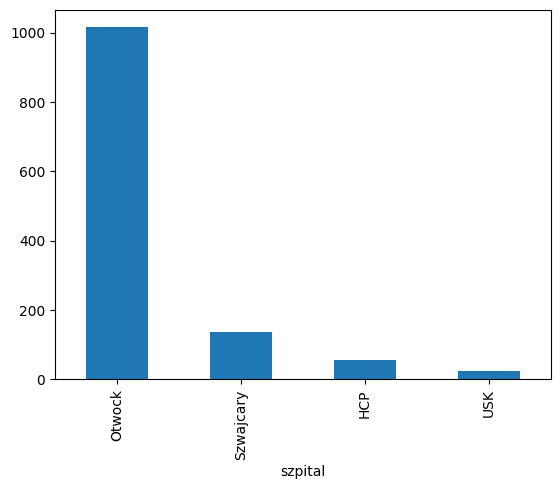

In [115]:
df["szpital"].value_counts().plot(kind="bar")
plt.show()

In [116]:
df_train = df[df["szpital"].isin(["Otwock", "USK", "HCP"])]
df_test = df[df["szpital"].isin(["Szwajcary"])]
print(f"Train set size: {len(df_train)} {len(df_train) / len(df) * 100:.2f}%")
print(f"Test set size: {len(df_test)} {len(df_test) / len(df) * 100:.2f}%")

Train set size: 1095 88.95%
Test set size: 136 11.05%


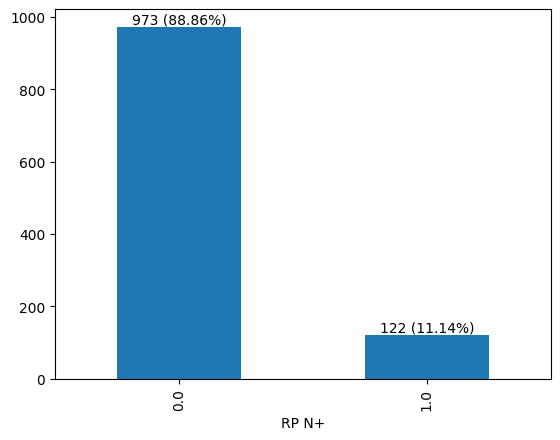

In [117]:
check_split(df_train, "RP N+")

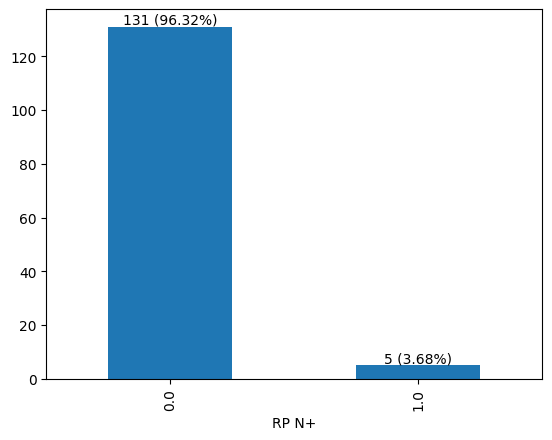

In [118]:
check_split(df_test, "RP N+")

In [ ]:
# TODO: duży imbalance

In [119]:
df_train, df_test = train_test_split(df, test_size=0.15, random_state=42, stratify=df["RP N+"])

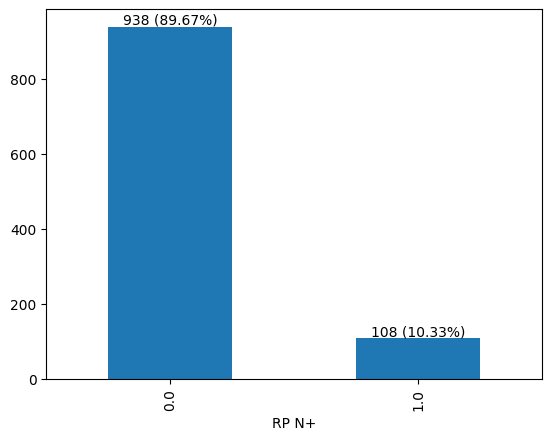

In [120]:
check_split(df_train, "RP N+")

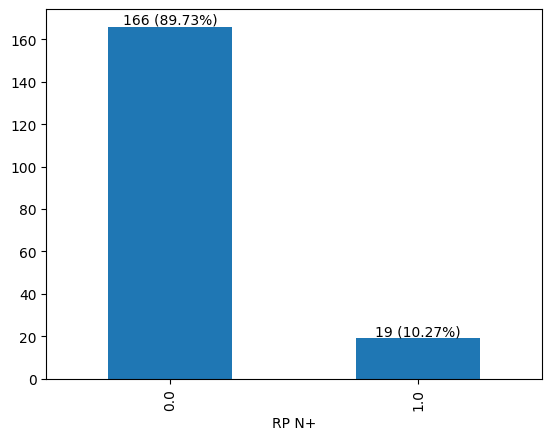

In [121]:
check_split(df_test, "RP N+")

In [122]:
df_train.to_csv("../data/train.csv", index=False)
df_test.to_csv("../data/test.csv", index=False)